In [2]:
#Montar mi google drive para poder usar los archivos
from google.colab import drive
drive.mount('/content/gdrive',  force_remount=True)

Mounted at /content/gdrive


In [3]:

def antiSpace(strParam):
  result = ''
  for ch in strParam:
    if ch != ' ' and ch != ',' and ch != '/' and ch != '1':
      result = result + ch
    else:
      result = result + '_'
  return result

# 1980-2022, without emerging sources downloaded January 18 2024

Data were retrieved from InCites, a bibliometric tool for research evaluation developed by Clarivate Analytics. Annual global outputs from 1980 to 2022 across the 22 research fields defined by the Essential Science Indicators (ESI) schema were downloaded using the Analyze -> Research Areas option, selecting the Trend checkbox. Country-level outputs for each ESI area were obtained via the Analyze -> Locations menu, filtering data by area under the ESI scheme and downloading 22 separate files containing country-specific information.

In [4]:
%cd /content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/Locations
!ls

/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/Locations
'Agricultural Sciences.xlsx'	 Mathematics.xlsx
'Biology & Biochemistry.xlsx'	 Microbiology.xlsx
 Chemistry.xlsx			'Molecular Biology & Genetics.xlsx'
'Clinical Medicine.xlsx'	 Multidisciplinary.xlsx
'Computer Science.xlsx'		'Neuroscience & Behavior.xlsx'
'Economics & Business.xlsx'	'Pharmacology & Toxicology.xlsx'
 Engineering.xlsx		 Physics.xlsx
 Environment_Ecology.xlsx	'Plant & Animal Science.xlsx'
 Geosciences.xlsx		 Psychiatry_Psychology.xlsx
 Immunology.xlsx		'Social Sciences, general.xlsx'
'Incites Locations Trend.xlsx'	'Space Science.xlsx'
'Materials Science.xlsx'


In [5]:
import pandas as pd
import numpy as np
import os
#
INDICADOR = 'Web of Science Documents'
YEAR = 'Publication Year'


In [6]:
# Read the files from the areas. IMPORTANT: Set the file names.
areas = ['Agricultural Sciences', 'Biology & Biochemistry', 'Chemistry', 'Clinical Medicine', 'Computer Science', 'Economics & Business',
         'Engineering', 'Environment/Ecology', 'Geosciences', 'Immunology', 'Materials Science', 'Mathematics', 'Microbiology',
         'Molecular Biology & Genetics', 'Multidisciplinary', 'Neuroscience & Behavior', 'Pharmacology & Toxicology', 'Physics', 'Plant & Animal Science',
         'Psychiatry/Psychology', 'Social Sciences, general', 'Space Science']

fileNames = {
              'Agricultural Sciences': 'Agricultural Sciences.xlsx',
             'Biology & Biochemistry': 'Biology & Biochemistry.xlsx',
             'Chemistry': 'Chemistry.xlsx',
             'Clinical Medicine':'Clinical Medicine.xlsx'	,
             'Computer Science':'Computer Science.xlsx',
             'Economics & Business':'Economics & Business.xlsx',
             'Engineering':'Engineering.xlsx',
             'Environment/Ecology':'Environment_Ecology.xlsx',
             'Geosciences':'Geosciences.xlsx',
             'Immunology':'Immunology.xlsx',
             'Materials Science':'Materials Science.xlsx',
             'Mathematics':'Mathematics.xlsx',
             'Microbiology':'Microbiology.xlsx',
             'Molecular Biology & Genetics':'Molecular Biology & Genetics.xlsx',
             'Multidisciplinary':'Multidisciplinary.xlsx',
             'Neuroscience & Behavior':'Neuroscience & Behavior.xlsx',
             'Pharmacology & Toxicology':'Pharmacology & Toxicology.xlsx',
             'Physics':'Physics.xlsx',
             'Plant & Animal Science':'Plant & Animal Science.xlsx',
             'Psychiatry/Psychology':'Psychiatry_Psychology.xlsx',
             'Social Sciences, general':'Social Sciences, general.xlsx',
             'Space Science':'Space Science.xlsx'
            }


df_Areas = {}
for area in areas:
  fName = fileNames[area]
  if fName != None:
    df_Areas[area] = pd.read_excel(fName, index_col=0)


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default sty

In [7]:
df_Areas['Agricultural Sciences']

,Web of Science Documents,Publication Year,Times Cited,Rank,% Docs Cited,Category Normalized Citation Impact,% First Author (2008-Present),% Documents in Top 1%,% International Collaborations,% Last Author (2008-Present),...,% Gold Documents,% Documents in Q1 Journals,% Gold - Hybrid Documents,% Documents in Q2 Journals,% Free to Read Documents,% Documents in Q3 Journals,% Documents in Q4 Journals,% Global Baseline (Docs),% Baseline for All Items (Docs),% All Open Access Documents
Name,,,,,,,,,,,,,,,,,,,,,
Global Baseline,15617.0,1980,195024.0,NaN,60.11,0.999807,NaN,0.97,2.06,NaN,...,0.39,NaN,0.10,NaN,5.65,NaN,NaN,100.00000,NaN,6.35
Global Baseline,14489.0,1981,188437.0,NaN,64.23,0.999862,NaN,0.97,2.42,NaN,...,0.52,NaN,0.15,NaN,6.78,NaN,NaN,100.00000,NaN,7.68
Global Baseline,15515.0,1982,191798.0,NaN,63.59,1.000001,NaN,0.97,2.48,NaN,...,0.43,NaN,0.14,NaN,7.21,NaN,NaN,100.00000,NaN,7.97
Global Baseline,15995.0,1983,213841.0,NaN,64.94,1.000003,NaN,0.96,2.51,NaN,...,0.53,NaN,0.12,NaN,7.15,NaN,NaN,100.00000,NaN,8.13
Global Baseline,15885.0,1984,224756.0,NaN,66.11,0.998932,NaN,0.97,2.83,NaN,...,0.43,NaN,0.11,NaN,6.65,NaN,NaN,100.00000,NaN,7.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TUVALU,NaN,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TUVALU,NaN,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TUVALU,NaN,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Generate the list of units. It is likely that all units exist in all files.
units = np.unique(df_Areas['Agricultural Sciences'].index)

for area in df_Areas:
  units_temp = np.unique(df_Areas[area].index)
  units = np.concatenate((units, units_temp), axis=None)
units = np.unique(units)
units

array(['AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'AMERICAN SAMOA', 'ANDORRA',
       'ANGOLA', 'ANTIGUA & BARBUDA', 'ARGENTINA', 'ARMENIA', 'AUSTRALIA',
       'AUSTRIA', 'AZERBAIJAN', 'BAHAMAS', 'BAHRAIN', 'BANGLADESH',
       'BARBADOS', 'BELARUS', 'BELGIUM', 'BELIZE', 'BENIN', 'BERMUDA',
       'BHUTAN', 'BOLIVIA', 'BOSNIA & HERZEGOVINA', 'BOTSWANA', 'BRAZIL',
       'BRUNEI', 'BULGARIA', 'BURKINA FASO', 'BURUNDI',
       'Baseline for All Items', 'CAMBODIA', 'CAMEROON', 'CANADA',
       'CAPE VERDE', 'CENT AFR REPUBL', 'CHAD', 'CHILE', 'CHINA MAINLAND',
       'COLOMBIA', 'COMOROS', 'CONGO DEMOCRATIC REPUBLIC',
       'CONGO PEOPLES REP', 'COOK ISLANDS', 'COSTA RICA', 'COTE IVOIRE',
       'CROATIA', 'CUBA', 'CYPRUS', 'CZECH REPUBLIC', 'CZECHOSLOVAKIA',
       'DENMARK', 'DJIBOUTI', 'DOMINICA', 'DOMINICAN REPUBLIC', 'ECUADOR',
       'EGYPT', 'EL SALVADOR', 'ENGLAND', 'EQUATORIAL GUINEA', 'ERITREA',
       'ESTONIA', 'ETHIOPIA', 'FIJI', 'FINLAND', 'FRANCE',
       'FRENCH GUIANA', 'FREN

In [9]:
# Create a production matrix Years × Areas for each country
df_units = {}
for unit in units:
  df_units[unit] =  pd.DataFrame()
  for area in fileNames:
    if fileNames[area] != None:
      #Dataframe con los datos de la unidad en el area
      if unit in df_Areas[area].index:
        dfUnit_Area = df_Areas[area].loc[unit]

        dfAreaUnit = dfUnit_Area[[YEAR, INDICADOR]].values
        if dfAreaUnit.size > 2:
          dfAreaUnit = pd.DataFrame({YEAR:dfAreaUnit[:,0], area:dfAreaUnit[:,1]})
          dfAreaUnit = dfAreaUnit.set_index(YEAR)
          if df_units[unit].empty:
            df_units[unit] =  dfAreaUnit
          else:
            df_units[unit] = pd.merge(df_units[unit], dfAreaUnit, on=YEAR, how='outer')
  df_units[unit].fillna(0, inplace=True)
  df_units[unit].sort_index(inplace=True)

In [10]:
## Areas' production over the years
df_areas=pd.DataFrame(index=df_units[unit].index)

for area in areas: #Number of papers is at 'Baseline for All Items'
  df_areas[area] = df_units['Baseline for All Items'][area]

df_areas.head()

,Agricultural Sciences,Biology & Biochemistry,Chemistry,Clinical Medicine,Computer Science,Economics & Business,Engineering,Environment/Ecology,Geosciences,Immunology,...,Microbiology,Molecular Biology & Genetics,Multidisciplinary,Neuroscience & Behavior,Pharmacology & Toxicology,Physics,Plant & Animal Science,Psychiatry/Psychology,"Social Sciences, general",Space Science
Publication Year,,,,,,,,,,,,,,,,,,,,,
1980.0,13794.0,43090.0,52955.0,103710.0,4116.0,8810.0,20522.0,5744.0,11138.0,6886.0,...,5669.0,13635.0,12099.0,11888.0,13349.0,31433.0,26955.0,15647.0,36395.0,4807.0
1981.0,13005.0,45566.0,52310.0,112509.0,4457.0,8993.0,20744.0,6683.0,12542.0,7352.0,...,5564.0,12409.0,11541.0,12749.0,13093.0,33832.0,28768.0,15875.0,36673.0,5142.0
1982.0,13924.0,48798.0,56267.0,118871.0,5505.0,9172.0,22187.0,7141.0,13363.0,9085.0,...,6067.0,15097.0,12742.0,13927.0,13748.0,32922.0,29565.0,17685.0,39124.0,4899.0
1983.0,14315.0,51300.0,58363.0,128627.0,5958.0,9882.0,25997.0,8290.0,13714.0,8892.0,...,6517.0,14336.0,14942.0,15697.0,14188.0,35345.0,32862.0,17347.0,40734.0,5290.0
1984.0,14456.0,52181.0,60558.0,133949.0,6476.0,9920.0,27310.0,8601.0,14324.0,9249.0,...,6682.0,14967.0,10943.0,17380.0,15874.0,37083.0,34270.0,18291.0,42215.0,5596.0


In [11]:
años = df_areas.index

In [12]:
# Explore a selected country's production
import matplotlib.pyplot as plt
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

selected_unit = 'USA'

def plotShare(Unit):
  selected_unit=Unit
  dft=df_units[Unit]
  dft.plot(figsize=(20,10), title = Unit)
  return Unit

w = interactive(plotShare, Unit=units)
display(w)

interactive(children=(Dropdown(description='Unit', options=('AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'AMERICAN SAM…

## The following chart uses the selected country in the last cell


In [13]:
import plotly.graph_objects as go

Unit = w.result
dft =df_units[Unit]
print(Unit)

figDocsMexico = go.Figure()
figDocsMexico.update_layout(width=1400, height=800, title=Unit+' , DOCS')
for column in dft.columns:
  figDocsMexico.add_trace( go.Scatter(x=dft.index, y=dft[column], name= column))

figDocsMexico.show()



AFGHANISTAN


# Indicators Calculation

In [14]:
years = df_areas.index
years

Index([1980.0, 1981.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0,
       1989.0, 1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0,
       1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0,
       2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0,
       2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0],
      dtype='float64', name='Publication Year')

In [15]:
# Read the global indicators of the areas.
unitsTrend = pd.read_excel("Incites Locations Trend.xlsx", index_col=0)
unitsTrend.head()


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default



,Web of Science Documents,Publication Year,Times Cited,Rank,% Docs Cited,Category Normalized Citation Impact,% First Author (2008-Present),% Documents in Top 1%,% International Collaborations,% Last Author (2008-Present),...,% Gold Documents,% Documents in Q1 Journals,% Gold - Hybrid Documents,% Documents in Q2 Journals,% Free to Read Documents,% Documents in Q3 Journals,% Documents in Q4 Journals,% Global Baseline (Docs),% Baseline for All Items (Docs),% All Open Access Documents
Name,,,,,,,,,,,,,,,,,,,,,
Global Baseline,518625.0,1980,9888041.0,NaN,64.66,0.998980,NaN,0.94,3.55,NaN,...,0.16,NaN,0.30,NaN,5.49,NaN,NaN,100.0,NaN,7.68
Global Baseline,537615.0,1981,10337001.0,NaN,65.39,0.999563,NaN,0.95,3.84,NaN,...,0.18,NaN,0.30,NaN,5.95,NaN,NaN,100.0,NaN,8.26
Global Baseline,571359.0,1982,10925310.0,NaN,64.84,0.999712,NaN,0.95,4.13,NaN,...,0.18,NaN,0.25,NaN,5.49,NaN,NaN,100.0,NaN,7.65
Global Baseline,620736.0,1983,11802190.0,NaN,63.46,0.999626,NaN,0.95,4.27,NaN,...,0.19,NaN,0.23,NaN,5.40,NaN,NaN,100.0,NaN,7.57
Global Baseline,640378.0,1984,12321060.0,NaN,63.97,0.999606,NaN,0.95,4.62,NaN,...,0.21,NaN,0.25,NaN,5.70,NaN,NaN,100.0,NaN,7.98


In [16]:
## Change directory
%cd '/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/Global Context/'
!ls

/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/Global Context
ai.txt		 FMEASURE.txt			  rsi.txt	     Wshare.txt
AMEASURE.txt	 GAggregation.txt		  scatterplots
AreasShare.xlsx  GMEASURE.txt			  scatterplots.html
figuras		 manuscriptFiguresAndTables.html  share.txt


In [17]:
# Annual production of the units (countries).
df_units_production = {}
df_units_production2024 = pd.DataFrame(columns = ['Documents'])

#First calculate the total production of each unit in each year
for unit in units:
  df_units_production[unit] = pd.DataFrame(index=df_units[unit].index, columns=['Documents'])
  dfT = unitsTrend.loc[[unit]]
  dfT.set_index('Publication Year', inplace=True)
  for year in df_units_production[unit].index:
    if year in dfT.index:
      df_units_production[unit].at[year, 'Documents'] = dfT.loc[year]['Web of Science Documents']
      if year == 2024:
        df_units_production2024.at[unit, 'Documents'] = dfT.loc[year]['Web of Science Documents']
    else:
      print('ERROR')

In [18]:
import math

def sqrtF(number):
  return math.sqrt(number)

In [19]:

#We use Baselines for all items as the WORLD PRODUCTION
#The following lines calculate world production
df_produc = pd.DataFrame(index=años, columns=['Documents'])
df_produc['Documents'] = df_units_production['Baseline for All Items']


# Calculate the annual share of each OD/OW area
df_areas_share = df_areas.copy()
for area in areas:
  df_areas_share[area] = df_areas[area] / df_produc.Documents # OD / OW


#Calculate the share in each area of ​​each country  OCD/OC
df_units_share={} # DShareC
df_units_wshare={} # CShareD
df_geometric_aggregation={}
for unit in units:
  df_units_share[unit] = df_units[unit].copy()
  df_units_wshare[unit] = df_units[unit].copy()
  df_geometric_aggregation[unit] = df_units[unit].copy()
  for area in fileNames:
      if fileNames[area] != None:
        if area in df_units_share[unit].columns:
          df_units_share[unit][area] = df_units[unit][area] / df_units_production[unit].Documents #OCD/OC
          df_units_production[unit]['Share'] = df_units_production[unit].Documents / df_produc.Documents # Country Share
          df_units_wshare[unit][area] = df_units[unit][area] / df_areas[area] # OCD/OWD
          # Geometric aggregation, same weight (1/2)
          df_geometric_aggregation[unit][area] = np.sqrt(df_units_share[unit][area].astype(float)) + np.sqrt(df_units_wshare[unit][area].astype(float))

#Calculate the activity index (AI)
df_units_AI={}
for unit in units:
  df_units_AI[unit] = df_units_share[unit].copy()
  for area in fileNames:
      if fileNames[area] != None:
        if area in df_units_AI[unit].columns:
          df_units_AI[unit][area] = df_units_share[unit][area] / df_areas_share[area]


#Calculate F-Measure
df_units_FMeasure={}
df_units_AMeasure={}
df_units_GMeasure={}
for unit in units:
  df_units_FMeasure[unit] = df_units_share[unit].copy()
  df_units_AMeasure[unit] = df_units_share[unit].copy()
  df_units_GMeasure[unit] = df_units_share[unit].copy()
  for area in fileNames:
      if fileNames[area] != None:
        if area in df_units_FMeasure[unit].columns:
          ODmasOC = df_areas[area] + df_units_production[unit].Documents # OD + OC
          df_units_FMeasure[unit][area] = 2*df_units[unit][area] / ODmasOC # 2*Ocd/(OD+OC)
          df_units_AMeasure[unit][area] = (df_units_share[unit][area] + df_units_wshare[unit][area])/2
          df_units_GMeasure[unit][area] = list(map(sqrtF, df_units_share[unit][area] * df_units_wshare[unit][area]))# Calculate squre root for each element


#Calculate the Relative Specialization Index (RSI)
df_units_RSI = {}
for unit in units:
  df_units_RSI[unit] = df_units_AI[unit].copy()
  for area in fileNames:
      if fileNames[area] != None:
        if area in df_units_RSI[unit].columns:
          df_units_RSI[unit][area] = (df_units_AI[unit][area] - 1) / (df_units_AI[unit][area] + 1)


def concatena(dataframes):
  result = pd.DataFrame(columns = np.append(['Unit Name'], areas))
  for unit in units:
    df_unit_temp = pd.DataFrame(columns = np.append(['Unit Name'], areas))
    for area in areas:
      if area in dataframes[unit].columns:
        df_unit_temp[area] = dataframes[unit][area]
    df_unit_temp['Unit Name'] = [str(e) + '_' + unit for e in dataframes[unit].index]
    frames = [df_unit_temp, result]
    result = pd.concat(frames)
  result.fillna(0, inplace=True)
  return result

#Create a dataframe with the evolution of all units and save into files
#### DShareC
df_allUnits_Share = concatena(df_units_share)
df_allUnits_Share.to_csv('share.txt', index=False, sep=';')

###   CShareD
df_allUnits_wShare = concatena(df_units_wshare)
df_allUnits_wShare.to_csv('Wshare.txt', index=False, sep=';')

df_allUnits_AI = concatena(df_units_AI)
df_allUnits_AI.to_csv('ai.txt', index=False, sep=';')

df_allUnits_RSI = concatena(df_units_RSI)
df_allUnits_RSI.to_csv('rsi.txt', index=False, sep=';')

df_allUnits_FMeasure = concatena(df_units_FMeasure)
df_allUnits_FMeasure.to_csv('FMEASURE.txt', index=False, sep=';')

#### geometric mean
df_allUnits_GMeasure = concatena(df_units_GMeasure)
df_allUnits_GMeasure.to_csv('GMEASURE.txt', index=False, sep=';')

#### arithmetic mean
df_allUnits_AMeasure = concatena(df_units_AMeasure)
df_allUnits_AMeasure.to_csv('AMEASURE.txt', index=False, sep=';')

#### Geometric Aggregation
df_allUnits_GAggregation = concatena(df_geometric_aggregation)
df_allUnits_GAggregation.to_csv('GAggregation.txt', index=False, sep=';')

/tmp/ipython-input-3431514716.py:77: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipython-input-3431514716.py:76: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipython-input-3431514716.py:76: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipython-input-3431514716.p

In [20]:
import matplotlib.pyplot as plt
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
selected_unit = 'USA'

def plotShare(Unit):
  selected_unit=Unit
  dft=df_units_share[Unit]
  dft.plot(figsize=(20,10), title = Unit+' - DShareC')
  return Unit

w = interactive(plotShare, Unit=units)
display(w)

interactive(children=(Dropdown(description='Unit', options=('AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'AMERICAN SAM…

In [21]:
import plotly.graph_objects as go

Unit = w.result
dft =df_units_share[Unit]
print(Unit)

figMex = go.Figure()
figMex.update_layout(width=1400, height=800, title= Unit+' - DShareC')
for column in dft.columns:
  figMex.add_trace( go.Scatter(x=dft.index, y=dft[column], name= column))
figMex.update_layout(
yaxis = dict(
tickfont = dict(size=20)))
figMex.show()


AFGHANISTAN


<Axes: xlabel='Publication Year'>

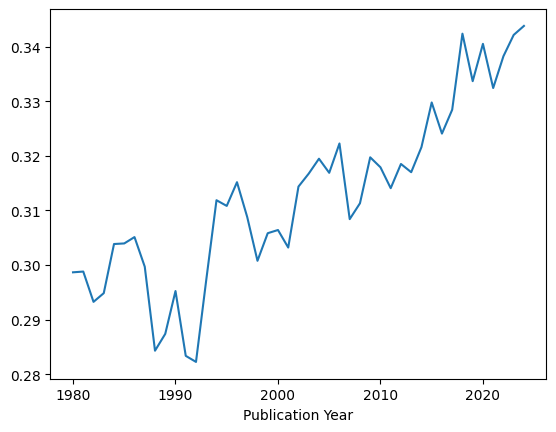

In [22]:
df_units_FMeasure['USA']['Clinical Medicine'].plot()

<Axes: xlabel='Publication Year'>

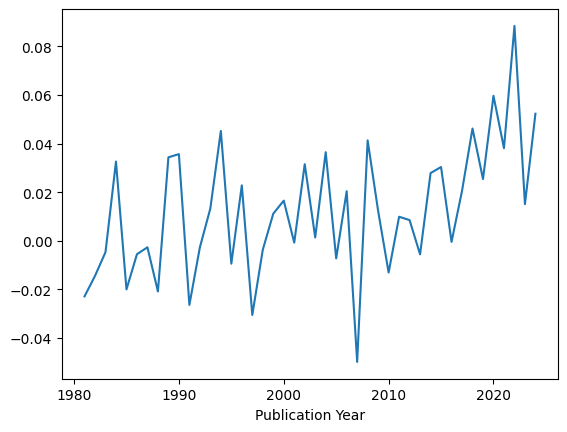

In [23]:
temp = df_units_AI['USA']['Clinical Medicine'] - df_units_AI['USA']['Clinical Medicine'].shift()
temp.plot()

<Axes: >

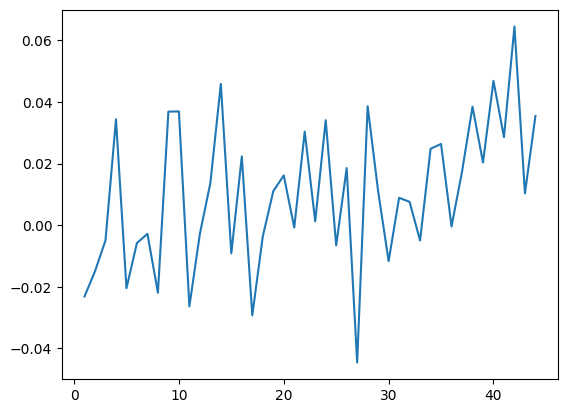

In [24]:
serieAI = pd.Series(df_units_AI['USA']['Clinical Medicine'].values.astype('float'))
serieAI.pct_change(periods=1).dropna().plot()

<Axes: >

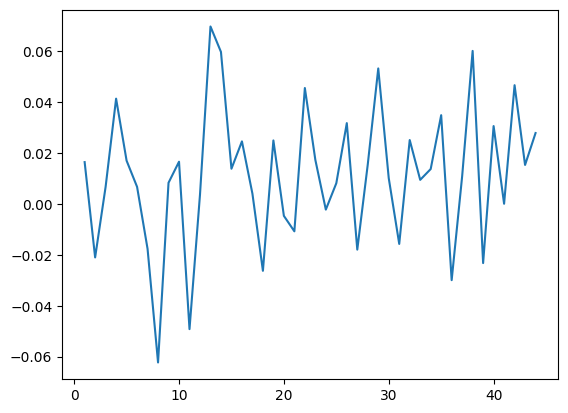

In [25]:
serieShare = pd.Series(df_units_share['USA']['Clinical Medicine'].values.astype('float'))
serieShare.pct_change(periods=1).dropna().plot()

# Correlations between indicators - Countries are the entities

In [26]:
#Remove 'Baseline for All Items' and 'Global Baseline'
units = list(units)
units.remove('Baseline for All Items')
units.remove('Global Baseline')
#units

In [27]:
listIndicators = ['Output','DShareC', 'CShareD', 'AI', 'RSI', 'FMeasure', 'Geometric Aggregtion']
listDfs = [df_units_production, df_units_share, df_units_wshare, df_units_AI, df_units_RSI, df_units_FMeasure,df_units_AMeasure, df_units_GMeasure, df_geometric_aggregation]

#Create dictionaries
dictCorrAreas = {}
dictCorrAreasDF = {}
dictCorrAreasDFAGMeans = {}
dictSpearmanCorrAreas = {}
dictSpearmanCorrAreasDF = {}
dictSpearmanCorrAreasDFAGMeans = {}


dictYearlyData = {}

#Create a dictionary in the dictionaries
for year in years:
  dictCorrAreas[year] = {}
  dictSpearmanCorrAreas[year] = {}
  dictCorrAreasDF[year] = pd.DataFrame(index = fileNames)
  dictCorrAreasDFAGMeans[year] = pd.DataFrame(index = fileNames)
  dictSpearmanCorrAreasDF[year] = pd.DataFrame(index = fileNames)
  dictSpearmanCorrAreasDFAGMeans[year] = pd.DataFrame(index = fileNames)
  dictYearlyData[year] = {}


  for area in fileNames:
    dfTemp = pd.DataFrame(index=units, columns = listIndicators)
    for unit in units:
      if not df_units_share[unit].empty and area in df_units_share[unit].columns and year in df_units_share[unit].index:
        dfTemp.at[unit, 'Output'] = df_units[unit][area][year].astype('float')
        dfTemp.at[unit, 'DShareC'] = df_units_share[unit][area][year].astype('float')
        dfTemp.at[unit, 'CShareD'] = df_units_wshare[unit][area][year].astype('float')
        dfTemp.at[unit, 'AI'] = df_units_AI[unit][area][year].astype('float')
        dfTemp.at[unit, 'RSI'] = df_units_RSI[unit][area][year].astype('float')
        dfTemp.at[unit, 'FMeasure'] = df_units_FMeasure[unit][area][year].astype('float')
        dfTemp.at[unit, 'AMean'] = df_units_AMeasure[unit][area][year].astype('float')
        dfTemp.at[unit, 'GMean'] = df_units_GMeasure[unit][area][year].astype('float')
        dfTemp.at[unit, 'Geometric Aggregtion'] = df_geometric_aggregation[unit][area][year].astype('float')
    dfTemp = dfTemp.dropna(how='all')
    dfTemp = dfTemp.astype('float')
    ## CORRELATION COEFFICIENTS
    dictCorrAreas[year][area] = dfTemp.corr(method='pearson')
    dictSpearmanCorrAreas[year][area] = dfTemp.corr(method='spearman')
    ## TESTS AND DATA



    #dictCorrAreasDF[year].at[area,'AI vs Output'] = dictCorrAreas[year][area].at['AI','Output']
    dictCorrAreasDF[year].at[area,'AI vs DShareC'] = dictCorrAreas[year][area].at['AI', 'DShareC']
    dictCorrAreasDF[year].at[area,'AI vs CShareD'] = dictCorrAreas[year][area].at['AI','CShareD']
    #dictCorrAreasDF[year].at[area,'F-Measure vs Output'] = dictCorrAreas[year][area].at['FMeasure','Output']
    dictCorrAreasDF[year].at[area,'F-Measure vs DShareC'] = dictCorrAreas[year][area].at['FMeasure', 'DShareC']
    dictCorrAreasDF[year].at[area,'F-Measure vs CShareD'] = dictCorrAreas[year][area].at['FMeasure', 'CShareD']
    #dictCorrAreasDF[year].at[area,'Geometric Aggregtion vs Output'] = dictCorrAreas[year][area].at['Geometric Aggregtion','Output']
    dictCorrAreasDF[year].at[area,'Geometric Aggregtion vs DShareC'] = dictCorrAreas[year][area].at['Geometric Aggregtion', 'DShareC']
    dictCorrAreasDF[year].at[area,'Geometric Aggregtion vs CShareD'] = dictCorrAreas[year][area].at['Geometric Aggregtion', 'CShareD']
    dictCorrAreasDF[year].at[area,'AI vs RSI'] = dictCorrAreas[year][area].at['AI','RSI']
    dictCorrAreasDF[year].at[area,'AI vs F-Measure'] = dictCorrAreas[year][area].at['AI','FMeasure']
    dictCorrAreasDF[year].at[area,'CShareD vs Output'] = dictCorrAreas[year][area].at['CShareD','Output']
    dictCorrAreasDF[year].at[area,'DShareC vs CShareD'] = dictCorrAreas[year][area].at['DShareC','CShareD']

    #dictSpearmanCorrAreasDF[year].at[area,'AI vs Output'] = dictSpearmanCorrAreas[year][area].at['AI','Output']
    dictSpearmanCorrAreasDF[year].at[area,'AI vs DShareC'] = dictSpearmanCorrAreas[year][area].at['AI', 'DShareC']
    dictSpearmanCorrAreasDF[year].at[area,'AI vs CShareD'] = dictSpearmanCorrAreas[year][area].at['AI','CShareD']
    #dictSpearmanCorrAreasDF[year].at[area,'F-Measure vs Output'] = dictSpearmanCorrAreas[year][area].at['FMeasure','Output']
    dictSpearmanCorrAreasDF[year].at[area,'F-Measure vs DShareC'] = dictSpearmanCorrAreas[year][area].at['FMeasure', 'DShareC']
    dictSpearmanCorrAreasDF[year].at[area,'F-Measure vs CShareD'] = dictSpearmanCorrAreas[year][area].at['FMeasure', 'CShareD']
    #dictSpearmanCorrAreasDF[year].at[area,'Geometric Aggregtion vs Output'] = dictSpearmanCorrAreas[year][area].at['Geometric Aggregtion','Output']
    dictSpearmanCorrAreasDF[year].at[area,'Geometric Aggregtion vs DShareC'] = dictSpearmanCorrAreas[year][area].at['Geometric Aggregtion', 'DShareC']
    dictSpearmanCorrAreasDF[year].at[area,'Geometric Aggregtion vs CShareD'] = dictSpearmanCorrAreas[year][area].at['Geometric Aggregtion', 'CShareD']
    dictSpearmanCorrAreasDF[year].at[area,'AI vs RSI'] = dictSpearmanCorrAreas[year][area].at['AI','RSI']
    dictSpearmanCorrAreasDF[year].at[area,'AI vs F-Measure'] = dictSpearmanCorrAreas[year][area].at['AI','FMeasure']
    dictSpearmanCorrAreasDF[year].at[area,'DShareC vs CShareD'] = dictSpearmanCorrAreas[year][area].at['DShareC','CShareD']

    #dictCorrAreasDFAGMeans[year].at[area,'A-Measure vs Output'] = dictCorrAreas[year][area].at['AMeasure','Output']
    dictCorrAreasDFAGMeans[year].at[area,'AMean vs DShareC'] = dictCorrAreas[year][area].at['AMean', 'DShareC']
    dictCorrAreasDFAGMeans[year].at[area,'AMean vs CShareD'] = dictCorrAreas[year][area].at['AMean','CShareD']
    dictCorrAreasDFAGMeans[year].at[area,'AMean vs F-Measure'] = dictCorrAreas[year][area].at['AMean','FMeasure']
    #dictCorrAreasDFAGMeans[year].at[area,'G-Measure vs Output'] = dictCorrAreas[year][area].at['GMeasure','Output']
    dictCorrAreasDFAGMeans[year].at[area,'GMean vs DShareC'] = dictCorrAreas[year][area].at['GMean', 'DShareC']
    dictCorrAreasDFAGMeans[year].at[area,'GMean vs CShareD'] = dictCorrAreas[year][area].at['GMean', 'CShareD']
    dictCorrAreasDFAGMeans[year].at[area,'GMean vs F-Measure'] = dictCorrAreas[year][area].at['GMean','FMeasure']

    #dictSpearmanCorrAreasDFAGMeans[year].at[area,'A-Measure vs Output'] = dictSpearmanCorrAreas[year][area].at['AMeasure','Output']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'AMean vs DShareC'] = dictSpearmanCorrAreas[year][area].at['AMean', 'DShareC']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'AMean vs CShareD'] = dictSpearmanCorrAreas[year][area].at['AMean','CShareD']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'AMean vs F-Measure'] = dictSpearmanCorrAreas[year][area].at['AMean','FMeasure']
    #dictSpearmanCorrAreasDFAGMeans[year].at[area,'G-Measure vs Output'] = dictSpearmanCorrAreas[year][area].at['GMeasure','Output']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'GMean vs DShareC'] = dictSpearmanCorrAreas[year][area].at['GMean', 'DShareC']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'GMean vs CShareD'] = dictSpearmanCorrAreas[year][area].at['GMean', 'CShareD']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'GMean vs F-Measure'] = dictSpearmanCorrAreas[year][area].at['GMean','FMeasure']

    dictYearlyData[year][area] = dfTemp


In [28]:
import os
import numpy as np
from scipy.stats import shapiro
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


text= '''
  <!DOCTYPE html>
  <html>
  <body>

  <br>
  <br>
  <h1>ScatterPlots</h1>
  <br>
  <br>
  <ul>
  '''


dicTests = {}
average = 0
os.makedirs('scatterplots', exist_ok = True)

for year in years:
  if year != 2024:
    continue
  os.makedirs('scatterplots/'+str(year), exist_ok = True)
  textScatterplots = '''
  <!DOCTYPE html>
  <html>
  <body>

  <br>
  <br>
  <h1>ScatterPlots '''+str(year)+'''+</h1>
  <br>
  <br>

  '''

  dicTests[year] = pd.DataFrame(index = fileNames)
  for area in fileNames:
    df = dictYearlyData[year][area].sort_values('Output', ascending=False)
    ## Select a subset indicators
    df = df[['Output','DShareC', 'CShareD', 'AI', 'FMeasure', 'RSI']]
    # Add the table to the html
    textScatterplots = textScatterplots +'''<br> <br> <h1>'''+ str(year) + " - "+area +'''</h1> <br><br>'''

    cm = sns.light_palette("lightblue", as_cmap=True)
    s = df.style.background_gradient(cmap=cm)
    textScatterplots = textScatterplots + s.to_html()
    textScatterplots = textScatterplots + '''<br><br>'''
    ## Create a pairplot with plotly
    fig = px.scatter_matrix(df,
                            dimensions=df.columns,
                            symbol=df.index,
                            title=str(year) + " - "+area)
    fig.update_traces(diagonal_visible=False)
    areaS = area.replace('/', '')
    figName = 'scatterplots/'+str(year)+'/'+str(year)+'_'+areaS
    figNamehtml = figName+'.html'
    #html
    fig.write_html(figNamehtml,
                   full_html=False,
                   include_plotlyjs='cdn')

    textScatterplots = textScatterplots + '''<a href="'''+figNamehtml.replace('scatterplots/', '')+'''">Plotly - '''+area+'''</a>'''

    textScatterplots = textScatterplots + '''
    <br><br>
    '''
    # Set a global font scale
    sns.set_theme(font_scale=1.6)
    #Create a pairplot with seaborn
    scatter_plot  = sns.pairplot(df)
    scatter_fig = scatter_plot.fig
    scatter_fig.savefig(figName+'.png')
    textScatterplots = textScatterplots + '''
    <img src="'''+figName.replace('scatterplots/', '')+'''.png" alt="'''+str(year) + ''' - '''+area+'''">
    <br><br>'''
    #Intent closing the figure
    plt.close()

    dicTests[year].at[area,'Number of Countries'] = len(df)
    for indicator in df.columns:
      stat, p = shapiro(df[indicator])
      if p > 0.05:
        dicTests[year].at[area, indicator +'-Shapiro' ] = 1
      else:
        dicTests[year].at[area, indicator +'-Shapiro' ] = 0
  ave =  dicTests[year]['Number of Countries'].mean()
  print(year, ' - ' , ave)
  average += ave
  #close html and save it
  textScatterplots = textScatterplots + '''  </body></html>'''

  file = open("scatterplots/scatterPlots_"+str(year)+".html","w")
  file.write(textScatterplots)
  file.close()
  text = text + '''<li><a href="'''+"scatterplots/scatterPlots_"+str(year)+".html"+'''">'''+str(year)+'''</a></li>'''





text = text + '''</ul> </body></html>'''
file = open("scatterplots.html","w")
file.write(text)
file.close()

average = average / len(years)
print('Average', average)


2024.0  -  209.95454545454547
Average 4.665656565656566


In [29]:
import plotly.express as px

fig = px.scatter_matrix(dfTemp,
    dimensions=dfTemp.columns,
                        symbol=dfTemp.index,
    title="Scatter matrix") # remove underscore
fig.update_traces(diagonal_visible=False)


fig.show()

In [30]:
import plotly.express as px

fig = px.scatter_matrix(dfTemp,
    dimensions=dfTemp.columns,
                        symbol=dfTemp.index,
    title="Scatter matrix") # remove underscore
fig.update_traces(diagonal_visible=False)

fig.update_layout(
    xaxis=dict(type='log'),
    yaxis=dict(type='log'),)


In [31]:
dfTemp.head()

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
AFGHANISTAN,3.0,0.006000,0.000160,0.865941,-0.071845,0.000311,0.090096,0.003080,0.000979
ALBANIA,4.0,0.006957,0.000213,1.003989,0.001991,0.000413,0.097997,0.003585,0.001217
ALGERIA,22.0,0.003260,0.001171,0.470457,-0.360121,0.001723,0.091313,0.002215,0.001954
ANDORRA,0.0,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
ANGOLA,0.0,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000


In [32]:
# x and y given as array_like objects
import plotly.express as px
fig = px.scatter(x=dfTemp['CShareD'], y=dfTemp['DShareC'])
fig.update_layout(
    xaxis=dict(type='log'),
    yaxis=dict(type='log'),)
fig.show()

# Create and html report

In [87]:
text = '''<h1>Manuscript figures and tables - Global Context</h1>

Pearson correlations in the year 2024 with countries as entities
'''

In [88]:
import seaborn as sns

def style_negative(v, props=''):
    return props if v < 0 else None

df = dictCorrAreasDF[2024].sort_values('F-Measure vs DShareC', ascending=False)
pd.set_option("styler.format.precision", 4)
cm = sns.light_palette("lightblue", as_cmap=True)

if(len(df) > 50):
  s = df.head(50).style.background_gradient(cmap=cm, vmin=0, vmax=1)
else:
  s = df.style.background_gradient(cmap=cm, vmin=0, vmax=1)
s.applymap(style_negative, props='color:red;')
text = text + s.to_html()

/tmp/ipython-input-2780162646.py:14: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



In [89]:
import seaborn as sns

df = dictCorrAreasDFAGMeans[2024]
pd.set_option("styler.format.precision", 4)
cm = sns.light_palette("lightblue", as_cmap=True)

if(len(df) > 50):
  s = df.head(50).style.background_gradient(cmap=cm, vmin=0, vmax=1)
else:
  s = df.style.background_gradient(cmap=cm, vmin=0, vmax=1)
s.applymap(style_negative, props='color:red;')
text = text + s.to_html()

/tmp/ipython-input-341907909.py:11: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



In [90]:
text = text + '''
<h1>Spearman correlations in the year 2024 with countries as entities</h1>
'''

In [91]:
import seaborn as sns

df = dictSpearmanCorrAreasDF[2024].sort_values('F-Measure vs DShareC', ascending=False)
pd.set_option("styler.format.precision", 4)
cm = sns.light_palette("lightblue", as_cmap=True)

#if(len(df) > 100):
#  s = df.head(100).style.background_gradient(cmap=cm)
#else:
#  s = df.style.background_gradient(cmap=cm)

s = df.style.background_gradient(cmap=cm, vmin=0, vmax=1)
s.applymap(style_negative, props='color:red;')
text = text + s.to_html()

/tmp/ipython-input-2992226174.py:13: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



In [92]:
import seaborn as sns

df = dictSpearmanCorrAreasDFAGMeans[2024]
pd.set_option("styler.format.precision", 4)
cm = sns.light_palette("lightblue", as_cmap=True)

#if(len(df) > 100):
#  s = df.head(100).style.background_gradient(cmap=cm)
#else:
#  s = df.style.background_gradient(cmap=cm)

s = df.style.background_gradient(cmap=cm, vmin=0, vmax=1)
s.applymap(style_negative, props='color:red;')
text = text + s.to_html()

/tmp/ipython-input-2210391947.py:13: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



### Charts

In [93]:
dictYearlyData[year][area]

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
AFGHANISTAN,3.0,0.006000,0.000160,0.865941,-0.071845,0.000311,0.090096,0.003080,0.000979
ALBANIA,4.0,0.006957,0.000213,1.003989,0.001991,0.000413,0.097997,0.003585,0.001217
ALGERIA,22.0,0.003260,0.001171,0.470457,-0.360121,0.001723,0.091313,0.002215,0.001954
ANDORRA,0.0,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
ANGOLA,0.0,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
WALES,192.0,0.024822,0.010219,3.582431,0.563550,0.014478,0.258641,0.017521,0.015927
YEMEN,1.0,0.000958,0.000053,0.138241,-0.757097,0.000101,0.038245,0.000506,0.000226
YUGOSLAVIA,0.0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
ZAMBIA,2.0,0.002273,0.000106,0.328008,-0.506015,0.000203,0.057991,0.001190,0.000492


In [94]:
import plotly.express as px
import plotly.graph_objs as go

# Tnaks to user171780 in https://stackoverflow.com/questions/61494278/plotly-how-to-make-a-figure-with-multiple-lines-and-shaded-area-for-standard-de
def line(error_y_mode=None, **kwargs):
    """Extension of `plotly.express.line` to use error bands."""
    ERROR_MODES = {'bar','band','bars','bands',None}
    if error_y_mode not in ERROR_MODES:
        raise ValueError(f"'error_y_mode' must be one of {ERROR_MODES}, received {repr(error_y_mode)}.")
    if error_y_mode in {'bar','bars',None}:
        fig = px.line(**kwargs)
    elif error_y_mode in {'band','bands'}:
        if 'error_y' not in kwargs:
            raise ValueError(f"If you provide argument 'error_y_mode' you must also provide 'error_y'.")
        figure_with_error_bars = px.line(**kwargs)
        fig = px.line(**{arg: val for arg,val in kwargs.items() if arg != 'error_y'})
        for data in figure_with_error_bars.data:
            x = list(data['x'])
            y_upper = list(data['y'] + data['error_y']['array'])
            y_lower = list(data['y'] - data['error_y']['array'] if data['error_y']['arrayminus'] is None else data['y'] - data['error_y']['arrayminus'])
            color = f"rgba({tuple(int(data['line']['color'].lstrip('#')[i:i+2], 16) for i in (0, 2, 4))},.3)".replace('((','(').replace('),',',').replace(' ','')
            fig.add_trace(
                go.Scatter(
                    x = x+x[::-1],
                    y = y_upper+y_lower[::-1],
                    fill = 'toself',
                    fillcolor = color,
                    line = dict(
                        color = 'rgba(255,255,255,0)'
                    ),
                    hoverinfo = "skip",
                    showlegend = False,
                    legendgroup = data['legendgroup'],
                    xaxis = data['xaxis'],
                    yaxis = data['yaxis'],
                )
            )
        # Reorder data as said here: https://stackoverflow.com/a/66854398/8849755
        reordered_data = []
        fig.update_layout(hovermode="x")
        for i in range(int(len(fig.data)/2)):
            reordered_data.append(fig.data[i+int(len(fig.data)/2)])
            reordered_data.append(fig.data[i])
        fig.data = tuple(reordered_data)
    return fig

# This function receives a dataframe containing de correlations
def makeMeanStdSeries(df, cols):
  dfResult = pd.DataFrame(columns=['Name', 'Year', 'Mean', 'Std'])
  for year in years:
    for col in cols:
      dft = df[year][[col]]
      dftDesception = dft.describe()
      dfResult.loc[len(dfResult.index)] = [col, year, dftDesception.at['mean', col], dftDesception.at['std', col]]
  return dfResult

def makeSeries(df, col):
  dfResult = pd.DataFrame(columns=['Domain Area', 'Year', col])
  for year in years:
    dft = df[year][[col]]
    for area in areas:
      dfResult.loc[len(dfResult.index)] = [area, year, dft.at[area, col]]#Agregar un renglon
  return dfResult

def makeAreaSeries(df, col):

  dfT = df[2024][[col]]
  minV = dfT.min().values[0]
  areaMin = dfT[dfT[col] == minV].index[0]
  maxV = dfT.max().values[0]
  areaMax = dfT[dfT[col] == maxV].index[0]

  dfResult = pd.DataFrame(columns=['Domain', 'Year', col])
  for year in years:
    dfAreaMax = df[year][[col]].loc[[areaMax]]
    dfAreaMax['Year'] = year
    dfAreaMax['Domain'] = areaMax
    dfResult = pd.concat([dfResult, dfAreaMax])
    dfAreaMin = df[year][[col]].loc[[areaMin]]
    dfAreaMin['Year'] = year
    dfAreaMin['Domain'] = areaMin
    dfResult = pd.concat([dfResult, dfAreaMin])
  return dfResult


In [95]:
df = makeSeries(dictCorrAreasDF, 'F-Measure vs DShareC')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020])]
fig = px.box(df, y="F-Measure vs DShareC", x="Year", color="Year",  points="all", title = 'Pearson Correlation',
          hover_data=df.columns)
fig.update_layout(
    font=dict(
        size=18,
    )
)
fig.show()

figName = 'figuras/pearson_correlation_longitudinal_fmeasure_nshare'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=True,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [96]:
df = makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs DShareC')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020])]
fig = px.box(df, y="F-Measure vs DShareC", x="Year", color="Year",  points="all", title = 'Spearman Correlation',
          hover_data=df.columns)
fig.update_layout(
    font=dict(
        size=18,
    ))
fig.show()

figName = 'figuras/spearman_correlation_longitudinal_fmeasure_nshare'
figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [97]:
df = makeSeries(dictCorrAreasDF, 'F-Measure vs CShareD')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020])]
fig = px.box(df, y="F-Measure vs CShareD", x="Year", color="Year",  points="all", title = 'Pearson Correlation',
          hover_data=df.columns)
fig.update_layout(
    font=dict(
        size=18,
    ))
fig.show()

figName = 'figuras/pearson_correlation_longitudinal_fmeasure_wshare'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [98]:
df =makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs DShareC')
df=df[df['Year']==2024]
df = df[['Domain Area', 'F-Measure vs DShareC']]
df = df.sort_values(by='F-Measure vs DShareC', ascending=False)
df

,Domain Area,F-Measure vs DShareC
989,Space Science,0.879743
978,Materials Science,0.804205
972,Computer Science,0.801694
985,Physics,0.772899
970,Chemistry,0.746491
979,Mathematics,0.694038
974,Engineering,0.685982
973,Economics & Business,0.681987
969,Biology & Biochemistry,0.673358
983,Neuroscience & Behavior,0.652216


In [99]:
df.describe()

,F-Measure vs DShareC
count,22.000000
mean,0.449049
std,0.339657
min,-0.201921
25%,0.085447
50%,0.572875
75%,0.692024
max,0.879743


In [100]:
df = makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs CShareD')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020])]
fig = px.box(df, y="F-Measure vs CShareD", x="Year", color="Year",  points="all", title = 'Spearman Correlation',
          hover_data=df.columns)
fig.update_layout(
    font=dict(
        size=18,
    ))
fig.show()

figName = 'figuras/spearman_correlation_longitudinal_fmeasure_wshare'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')

text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [101]:
dfT = makeMeanStdSeries(dictCorrAreasDF, ['F-Measure vs DShareC', 'F-Measure vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/pearson_correlation_evolution_fmeasure'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [102]:
dfT = makeMeanStdSeries(dictSpearmanCorrAreasDF, ['F-Measure vs DShareC', 'F-Measure vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Spearman Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/spearman_correlation_evolution_fmeasure'


figNamehtml = figName+'.html'
#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [103]:
dfT = makeMeanStdSeries(dictCorrAreasDF, ['Geometric Aggregtion vs DShareC', 'Geometric Aggregtion vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/pearson_correlation_evolution_Geometric_aggregtion'


figNamehtml = figName+'.html'
#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [104]:
dfT = makeMeanStdSeries(dictCorrAreasDF, ['AI vs DShareC', 'AI vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'band', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/pearson_correlation_evolution_AI'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [105]:
dfT = makeMeanStdSeries(dictSpearmanCorrAreasDF, ['AI vs DShareC', 'AI vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'band', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Spearman Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/spearman_correlation_evolution_AI'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [106]:
df = makeSeries(dictCorrAreasDF, 'AI vs CShareD')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020])]
fig = px.box(df, y="AI vs CShareD", x="Year", color="Year",  points="all", title = 'Pearson Correlation',
          hover_data=df.columns)
fig.show()

figName = 'figuras/pearson_correlation_longitudinal_AI_wshare'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [107]:

dfT = makeMeanStdSeries(dictCorrAreasDFAGMeans, ['AMean vs DShareC', 'AMean vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/pearson_correlation_evolution_A-Measure'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [108]:

dfT = makeMeanStdSeries(dictSpearmanCorrAreasDFAGMeans, ['AMean vs DShareC', 'AMean vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Spearman Correlation',
        markers = '.',
    )
fig.show()


figName = 'figuras/spearman_correlation_evolution_A-Measure'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [109]:

dfT = makeMeanStdSeries(dictCorrAreasDFAGMeans, ['GMean vs DShareC', 'GMean vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()


figName = 'figuras/pearson_correlation_evolution_G-Measure'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [110]:
dfT = makeMeanStdSeries(dictSpearmanCorrAreasDFAGMeans, ['GMean vs DShareC', 'GMean vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Spearman Correlation',
        markers = '.',
    )
fig.show()


figName = 'figuras/spearman_correlation_evolution_G-Measure'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [111]:
import plotly.express as px

col = 'F-Measure vs DShareC'
df = makeAreaSeries(dictCorrAreasDF, col)

fig = px.line(df, x="Year", y=col, color='Domain', title = 'Pearson Correlation', markers = '.')
fig.show()


figName = 'figuras/pearson_correlation_evolution_FMeasureDShareC2Areas'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''


/tmp/ipython-input-3487044262.py:78: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [112]:
import plotly.express as px

col = 'F-Measure vs DShareC'
df = makeAreaSeries(dictSpearmanCorrAreasDF, col)

fig = px.line(df, x="Year", y=col, color='Domain', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/spearman_correlation_best_worst_fmeasure_nshare'

figNamehtml = figName+'.html'
#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

/tmp/ipython-input-3487044262.py:78: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [113]:
col = 'AI vs CShareD'
df = makeAreaSeries(dictSpearmanCorrAreasDF, col)

fig = px.line(df, x="Year", y=col, color='Domain', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/spearman_correlation_best_worst_ai_wshare'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

/tmp/ipython-input-3487044262.py:78: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [114]:
import plotly.express as px

df = makeSeries(dictCorrAreasDF, 'F-Measure vs DShareC')
fig = px.line(df, x="Year", y="F-Measure vs DShareC", color='Domain Area',  title = 'Pearson Correlation', markers = '.')
fig.show()

figName = 'figuras/pearson_correlation_fmeasure_DShareC_alldomains'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [115]:
import plotly.express as px

df = makeSeries(dictCorrAreasDF, 'F-Measure vs CShareD')
fig = px.line(df, x="Year", y="F-Measure vs CShareD", color='Domain Area', title = 'Pearson Correlation', markers = '.')
fig.show()

figName = 'figuras/pearson_correlation_fmeasure_CShareD_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [116]:
import plotly.express as px

df = makeSeries(dictCorrAreasDF, 'AI vs DShareC')
fig = px.line(df, x="Year", y="AI vs DShareC", color='Domain Area',  title = 'Pearson Correlation', markers = '.')
fig.show()


figName = 'figuras/pearson_correlation_AI_DShareC_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [117]:
import plotly.express as px

df = makeSeries(dictCorrAreasDF, 'AI vs CShareD')
fig = px.line(df, x="Year", y="AI vs CShareD", color='Domain Area',  title = 'Pearson Correlation', markers = '.')
fig.show()

figName = 'figuras/pearson_correlation_AI_CShareD_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [118]:
import plotly.express as px

df = makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs DShareC')
fig = px.line(df, x="Year", y="F-Measure vs DShareC", color='Domain Area', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/Spearman_correlation_fmeasure_DShareC_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [119]:
import plotly.express as px

df = makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs CShareD')
fig = px.line(df, x="Year", y="F-Measure vs CShareD", color='Domain Area', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/Spearman_correlation_fmeasure_CShareD_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [120]:
import plotly.express as px

df = makeSeries(dictSpearmanCorrAreasDF, 'AI vs DShareC')
fig = px.line(df, x="Year", y="AI vs DShareC", color='Domain Area', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/Spearman_correlation_AI_DShareC_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [121]:
import plotly.express as px

df = makeSeries(dictSpearmanCorrAreasDF, 'AI vs CShareD')
fig = px.line(df, x="Year", y="AI vs CShareD", color='Domain Area', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/Spearman_correlation_AI_CShareD_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

# Tables

In [122]:
print(year)
dictCorrAreas[year][area].style.format(precision=2)

2024.0


,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.00,0.07,1.00,0.07,0.34,0.65,0.75,0.80,0.84
DShareC,0.07,1.00,0.07,1.00,0.40,0.19,0.49,0.65,0.27
CShareD,1.00,0.07,1.00,0.07,0.34,0.65,0.75,0.80,0.84
AI,0.07,1.00,0.07,1.00,0.40,0.19,0.49,0.65,0.27
RSI,0.34,0.40,0.34,0.40,1.00,0.63,0.81,0.50,0.62
FMeasure,0.65,0.19,0.65,0.19,0.63,1.00,0.84,0.61,0.94
Geometric Aggregtion,0.75,0.49,0.75,0.49,0.81,0.84,1.00,0.86,0.92
AMean,0.80,0.65,0.80,0.65,0.50,0.61,0.86,1.00,0.80
GMean,0.84,0.27,0.84,0.27,0.62,0.94,0.92,0.80,1.00


In [123]:
dictCorrAreasDF[2024].style.format(precision=2)

,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,CShareD vs Output,DShareC vs CShareD
Agricultural Sciences,1.00,-0.02,-0.01,0.69,0.67,0.52,0.78,-0.01,1.00,-0.02
Biology & Biochemistry,1.00,0.18,0.35,0.78,0.78,0.65,0.95,0.35,1.00,0.18
Chemistry,1.00,0.20,0.36,0.87,0.86,0.52,0.95,0.36,1.00,0.20
Clinical Medicine,1.00,0.04,0.05,0.97,0.82,0.46,0.90,0.05,1.00,0.04
Computer Science,1.00,0.18,0.44,0.72,0.77,0.61,0.90,0.44,1.00,0.18
Economics & Business,1.00,0.12,0.33,0.70,0.68,0.69,0.87,0.33,1.00,0.12
Engineering,1.00,0.19,0.29,0.93,0.87,0.50,0.94,0.29,1.00,0.19
Environment/Ecology,1.00,-0.13,-0.26,0.73,0.72,0.42,0.78,-0.26,1.00,-0.13
Geosciences,1.00,-0.02,-0.06,0.72,0.65,0.56,0.78,-0.06,1.00,-0.02
Immunology,1.00,-0.08,-0.13,0.69,0.72,0.41,0.54,-0.13,1.00,-0.08


In [124]:
dictCorrAreasDF[2022].style.format(precision=2)

,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,CShareD vs Output,DShareC vs CShareD
Agricultural Sciences,1.00,-0.02,0.05,0.70,0.68,0.56,0.90,0.05,1.00,-0.02
Biology & Biochemistry,1.00,0.16,0.29,0.80,0.75,0.65,0.93,0.29,1.00,0.16
Chemistry,1.00,0.21,0.36,0.88,0.87,0.53,0.96,0.36,1.00,0.21
Clinical Medicine,1.00,0.09,0.11,0.97,0.82,0.55,0.95,0.11,1.00,0.09
Computer Science,1.00,0.17,0.38,0.75,0.77,0.61,0.91,0.38,1.00,0.17
Economics & Business,1.00,0.14,0.33,0.72,0.69,0.70,0.87,0.33,1.00,0.14
Engineering,1.00,0.21,0.33,0.92,0.88,0.50,0.95,0.33,1.00,0.21
Environment/Ecology,1.00,-0.15,-0.26,0.79,0.69,0.45,0.81,-0.26,1.00,-0.15
Geosciences,1.00,-0.02,-0.05,0.75,0.63,0.59,0.76,-0.05,1.00,-0.02
Immunology,1.00,-0.10,-0.15,0.71,0.72,0.46,0.73,-0.15,1.00,-0.10


In [125]:
dictCorrAreasDF[year].describe().style.format(precision=2)

,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,CShareD vs Output,DShareC vs CShareD
count,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00
mean,1.00,0.06,0.15,0.74,0.70,0.58,0.81,0.15,1.00,0.06
std,0.00,0.12,0.22,0.13,0.13,0.11,0.14,0.22,0.00,0.12
min,1.00,-0.13,-0.26,0.35,0.34,0.41,0.40,-0.26,1.00,-0.13
25%,1.00,-0.02,-0.01,0.69,0.66,0.51,0.78,-0.01,1.00,-0.02
50%,1.00,0.06,0.19,0.73,0.72,0.59,0.85,0.19,1.00,0.06
75%,1.00,0.17,0.32,0.79,0.78,0.65,0.90,0.32,1.00,0.17
max,1.00,0.31,0.52,0.97,0.87,0.77,0.95,0.52,1.00,0.31


In [126]:
dictCorrAreasDF[1980].style.format(precision=2)

,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,CShareD vs Output,DShareC vs CShareD
Agricultural Sciences,1.00,-0.03,-0.01,0.62,0.82,0.32,0.69,-0.01,1.00,-0.03
Biology & Biochemistry,1.00,0.07,0.16,0.82,0.78,0.42,0.75,0.16,1.00,0.07
Chemistry,1.00,0.07,0.16,0.82,0.82,0.39,0.78,0.16,1.00,0.07
Clinical Medicine,1.00,0.03,0.06,0.93,0.88,0.32,0.90,0.06,1.00,0.03
Computer Science,1.00,0.05,0.14,0.56,0.53,0.67,0.61,0.14,1.00,0.05
Economics & Business,1.00,0.04,0.12,0.69,0.66,0.59,0.69,0.12,1.00,0.04
Engineering,1.00,0.05,0.12,0.74,0.78,0.47,0.85,0.12,1.00,0.05
Environment/Ecology,1.00,-0.02,-0.03,0.55,0.70,0.42,0.49,-0.03,1.00,-0.02
Geosciences,1.00,-0.01,0.01,0.65,0.74,0.43,0.58,0.01,1.00,-0.01
Immunology,1.00,0.03,0.13,0.53,0.68,0.55,0.72,0.13,1.00,0.03


In [127]:
dictSpearmanCorrAreasDF[year].style.format(precision=3)

,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,DShareC vs CShareD
Agricultural Sciences,1.000,0.243,0.267,0.999,0.803,0.662,1.000,0.267,0.243
Biology & Biochemistry,1.000,0.662,0.673,1.000,0.925,0.862,1.000,0.673,0.662
Chemistry,1.000,0.740,0.746,1.000,0.947,0.884,1.000,0.746,0.740
Clinical Medicine,1.000,0.029,0.032,1.000,0.905,0.336,1.000,0.032,0.029
Computer Science,1.000,0.786,0.802,0.999,0.948,0.920,1.000,0.802,0.786
Economics & Business,1.000,0.652,0.682,0.998,0.884,0.895,1.000,0.682,0.652
Engineering,1.000,0.677,0.686,1.000,0.951,0.819,1.000,0.686,0.677
Environment/Ecology,1.000,-0.212,-0.202,1.000,0.697,0.336,1.000,-0.202,-0.212
Geosciences,1.000,0.197,0.214,1.000,0.828,0.576,1.000,0.214,0.197
Immunology,1.000,-0.001,0.027,0.999,0.822,0.419,1.000,0.027,-0.001


In [128]:
dictSpearmanCorrAreasDF[year].describe().style.format(precision=2)

,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,DShareC vs CShareD
count,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00,22.00
mean,1.00,0.43,0.45,1.00,0.86,0.72,1.00,0.45,0.43
std,0.00,0.34,0.34,0.01,0.09,0.21,0.00,0.34,0.34
min,1.00,-0.21,-0.20,0.97,0.67,0.34,1.00,-0.20,-0.21
25%,1.00,0.07,0.09,1.00,0.82,0.58,1.00,0.09,0.07
50%,1.00,0.55,0.57,1.00,0.89,0.83,1.00,0.57,0.55
75%,1.00,0.68,0.69,1.00,0.94,0.89,1.00,0.69,0.68
max,1.00,0.84,0.88,1.00,0.96,0.95,1.00,0.88,0.84


In [129]:
dictCorrAreasDFAGMeans[year].style.format(precision=2)

,AMean vs DShareC,AMean vs CShareD,AMean vs F-Measure,GMean vs DShareC,GMean vs CShareD,GMean vs F-Measure
Agricultural Sciences,0.74,0.66,0.46,0.08,0.84,0.95
Biology & Biochemistry,0.61,0.89,0.79,0.38,0.87,0.97
Chemistry,0.85,0.69,0.74,0.49,0.86,0.98
Clinical Medicine,0.98,0.25,0.25,0.06,0.89,0.96
Computer Science,0.57,0.91,0.79,0.48,0.87,0.95
Economics & Business,0.51,0.92,0.74,0.38,0.85,0.96
Engineering,0.88,0.64,0.68,0.42,0.89,0.98
Environment/Ecology,0.90,0.31,0.07,-0.15,0.84,0.95
Geosciences,0.74,0.66,0.44,0.01,0.88,0.95
Immunology,0.94,0.27,0.11,0.02,0.83,0.91


In [130]:
dictCorrAreasDFAGMeans[year].describe().style.format(precision=2)

,AMean vs DShareC,AMean vs CShareD,AMean vs F-Measure,GMean vs DShareC,GMean vs CShareD,GMean vs F-Measure
count,22.00,22.00,22.00,22.00,22.00,22.00
mean,0.71,0.69,0.54,0.23,0.86,0.95
std,0.20,0.24,0.25,0.21,0.03,0.04
min,0.10,0.25,0.07,-0.15,0.79,0.79
25%,0.61,0.63,0.37,0.07,0.84,0.95
50%,0.70,0.75,0.61,0.25,0.85,0.96
75%,0.87,0.88,0.74,0.39,0.88,0.97
max,0.98,0.99,0.85,0.53,0.90,0.98


In [131]:
dictSpearmanCorrAreasDFAGMeans[year].style.format(precision=2)

,AMean vs DShareC,AMean vs CShareD,AMean vs F-Measure,GMean vs DShareC,GMean vs CShareD,GMean vs F-Measure
Agricultural Sciences,0.92,0.46,0.47,0.41,0.98,0.98
Biology & Biochemistry,0.97,0.76,0.77,0.75,0.99,0.99
Chemistry,0.98,0.80,0.81,0.81,0.99,0.99
Clinical Medicine,0.98,0.10,0.11,0.17,0.99,0.99
Computer Science,0.97,0.87,0.88,0.86,0.99,0.99
Economics & Business,0.93,0.82,0.84,0.76,0.98,0.99
Engineering,0.99,0.73,0.74,0.77,0.99,0.99
Environment/Ecology,0.89,0.02,0.03,-0.01,0.97,0.97
Geosciences,0.93,0.40,0.41,0.39,0.97,0.97
Immunology,0.91,0.24,0.26,0.33,0.92,0.92


In [132]:
dictSpearmanCorrAreasDFAGMeans[year].describe().style.format(precision=2)

,AMean vs DShareC,AMean vs CShareD,AMean vs F-Measure,GMean vs DShareC,GMean vs CShareD,GMean vs F-Measure
count,22.00,22.00,22.00,22.00,22.00,22.00
mean,0.93,0.59,0.60,0.57,0.98,0.98
std,0.06,0.29,0.29,0.28,0.02,0.02
min,0.71,0.02,0.03,-0.01,0.92,0.92
25%,0.92,0.38,0.41,0.35,0.97,0.97
50%,0.95,0.73,0.74,0.66,0.98,0.99
75%,0.97,0.82,0.83,0.78,0.99,0.99
max,0.99,0.93,0.94,0.92,0.99,0.99


In [133]:
dictCorrAreas[2024]['Clinical Medicine']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,0.035937,1.000000,0.035937,0.067102,0.968832,0.459064,0.249023,0.888914
DShareC,0.035937,1.000000,0.035937,1.000000,0.901545,0.046093,0.822137,0.976821,0.064832
CShareD,1.000000,0.035937,1.000000,0.035937,0.067102,0.968832,0.459064,0.249023,0.888914
AI,0.035937,1.000000,0.035937,1.000000,0.901545,0.046093,0.822137,0.976821,0.064832
RSI,0.067102,0.901545,0.067102,0.901545,1.000000,0.093210,0.884666,0.888081,0.145990
FMeasure,0.968832,0.046093,0.968832,0.046093,0.093210,1.000000,0.506127,0.252190,0.963376
Geometric Aggregtion,0.459064,0.822137,0.459064,0.822137,0.884666,0.506127,1.000000,0.895082,0.557986
AMean,0.249023,0.976821,0.249023,0.976821,0.888081,0.252190,0.895082,1.000000,0.253232
GMean,0.888914,0.064832,0.888914,0.064832,0.145990,0.963376,0.557986,0.253232,1.000000


In [134]:
dictCorrAreas[1980]['Clinical Medicine']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,0.033254,1.000000,0.033254,0.081799,0.928732,0.317101,0.241745,0.851027
DShareC,0.033254,1.000000,0.033254,1.000000,0.900638,0.064260,0.875880,0.977842,0.164687
CShareD,1.000000,0.033254,1.000000,0.033254,0.081799,0.928732,0.317101,0.241745,0.851027
AI,0.033254,1.000000,0.033254,1.000000,0.900638,0.064260,0.875880,0.977842,0.164687
RSI,0.081799,0.900638,0.081799,0.900638,1.000000,0.130496,0.958393,0.891542,0.247313
FMeasure,0.928732,0.064260,0.928732,0.064260,0.130496,1.000000,0.383808,0.256921,0.958546
Geometric Aggregtion,0.317101,0.875880,0.317101,0.875880,0.958393,0.383808,1.000000,0.916791,0.492442
AMean,0.241745,0.977842,0.241745,0.977842,0.891542,0.256921,0.916791,1.000000,0.338147
GMean,0.851027,0.164687,0.851027,0.164687,0.247313,0.958546,0.492442,0.338147,1.000000


In [135]:
dictCorrAreas[2024]['Mathematics']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,0.058328,1.000000,0.058328,0.153862,0.638616,0.592413,0.788171,0.794048
DShareC,0.058328,1.000000,0.058328,1.000000,0.826700,0.259309,0.696322,0.660381,0.356569
CShareD,1.000000,0.058328,1.000000,0.058328,0.153862,0.638616,0.592413,0.788171,0.794048
AI,0.058328,1.000000,0.058328,1.000000,0.826700,0.259309,0.696322,0.660381,0.356569
RSI,0.153862,0.826700,0.153862,0.826700,1.000000,0.412490,0.846655,0.625402,0.485683
FMeasure,0.638616,0.259309,0.638616,0.259309,0.412490,1.000000,0.766985,0.640240,0.950379
Geometric Aggregtion,0.592413,0.696322,0.592413,0.696322,0.846655,0.766985,1.000000,0.874907,0.854618
AMean,0.788171,0.660381,0.788171,0.660381,0.625402,0.640240,0.874907,1.000000,0.817119
GMean,0.794048,0.356569,0.794048,0.356569,0.485683,0.950379,0.854618,0.817119,1.000000


In [136]:
dictCorrAreas[1980]['Mathematics']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,0.007197,1.000000,0.007197,0.146838,0.610095,0.499287,0.585382,0.826119
DShareC,0.007197,1.000000,0.007197,1.000000,0.614918,0.054867,0.671462,0.814950,0.203406
CShareD,1.000000,0.007197,1.000000,0.007197,0.146838,0.610095,0.499287,0.585382,0.826119
AI,0.007197,1.000000,0.007197,1.000000,0.614918,0.054867,0.671462,0.814950,0.203406
RSI,0.146838,0.614918,0.146838,0.614918,1.000000,0.383459,0.882105,0.583662,0.463278
FMeasure,0.610095,0.054867,0.610095,0.054867,0.383459,1.000000,0.644418,0.398064,0.919213
Geometric Aggregtion,0.499287,0.671462,0.499287,0.671462,0.882105,0.644418,1.000000,0.833767,0.770338
AMean,0.585382,0.814950,0.585382,0.814950,0.583662,0.398064,0.833767,1.000000,0.643692
GMean,0.826119,0.203406,0.826119,0.203406,0.463278,0.919213,0.770338,0.643692,1.000000


In [137]:
dictCorrAreas[2024]['Space Science']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,0.067784,1.000000,0.067784,0.342449,0.652550,0.751914,0.801977,0.841283
DShareC,0.067784,1.000000,0.067784,1.000000,0.402466,0.187300,0.486166,0.650342,0.269013
CShareD,1.000000,0.067784,1.000000,0.067784,0.342449,0.652550,0.751914,0.801977,0.841283
AI,0.067784,1.000000,0.067784,1.000000,0.402466,0.187300,0.486166,0.650342,0.269013
RSI,0.342449,0.402466,0.342449,0.402466,1.000000,0.626064,0.810112,0.501707,0.615119
FMeasure,0.652550,0.187300,0.652550,0.187300,0.626064,1.000000,0.836770,0.608989,0.944961
Geometric Aggregtion,0.751914,0.486166,0.751914,0.486166,0.810112,0.836770,1.000000,0.863585,0.918623
AMean,0.801977,0.650342,0.801977,0.650342,0.501707,0.608989,0.863585,1.000000,0.801613
GMean,0.841283,0.269013,0.841283,0.269013,0.615119,0.944961,0.918623,0.801613,1.000000


In [138]:
dictCorrAreas[1980]['Space Science']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,0.035740,1.000000,0.035740,0.224641,0.509980,0.621490,0.836148,0.796806
DShareC,0.035740,1.000000,0.035740,1.000000,0.563312,0.228283,0.569470,0.578038,0.300617
CShareD,1.000000,0.035740,1.000000,0.035740,0.224641,0.509980,0.621490,0.836148,0.796806
AI,0.035740,1.000000,0.035740,1.000000,0.563312,0.228283,0.569470,0.578038,0.300617
RSI,0.224641,0.563312,0.224641,0.563312,1.000000,0.665411,0.858155,0.492603,0.622311
FMeasure,0.509980,0.228283,0.509980,0.228283,0.665411,1.000000,0.832056,0.541709,0.902639
Geometric Aggregtion,0.621490,0.569470,0.621490,0.569470,0.858155,0.832056,1.000000,0.820023,0.904734
AMean,0.836148,0.578038,0.836148,0.578038,0.492603,0.541709,0.820023,1.000000,0.815613
GMean,0.796806,0.300617,0.796806,0.300617,0.622311,0.902639,0.904734,0.815613,1.000000


In [139]:
text = text + '''</div>'''
file = open("manuscriptFiguresAndTables.html","w")
file.write(text)
file.close()